## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("financial_loan.csv")

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2/11/2021,9/13/2021,4/13/2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,1/1/2021,12/14/2021,1/15/2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,1/5/2021,12/12/2021,1/9/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2/25/2021,12/12/2021,3/12/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,1/1/2021,12/14/2021,1/15/2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,7/11/2021,5/16/2021,5/16/2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,10/11/2021,4/16/2021,5/16/2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,9/11/2021,5/16/2021,5/16/2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,10/11/2021,5/16/2021,5/16/2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,7/11/2021,5/16/2021,5/16/2021,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [5]:
print("No of rows: {}, No of columns: {}".format(df.shape[0], df.shape[1]))

No of rows: 38576, No of columns: 24


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   application_type       38576 non-null  str    
 3   emp_length             38576 non-null  str    
 4   emp_title              37138 non-null  str    
 5   grade                  38576 non-null  str    
 6   home_ownership         38576 non-null  str    
 7   issue_date             38576 non-null  str    
 8   last_credit_pull_date  38576 non-null  str    
 9   last_payment_date      38576 non-null  str    
 10  loan_status            38576 non-null  str    
 11  next_payment_date      38576 non-null  str    
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  str    
 14  sub_grade              38576 non-null  str    
 15  term         

## Data types

In [7]:
df.dtypes

id                         int64
address_state                str
application_type             str
emp_length                   str
emp_title                    str
grade                        str
home_ownership               str
issue_date                   str
last_credit_pull_date        str
last_payment_date            str
loan_status                  str
next_payment_date            str
member_id                  int64
purpose                      str
sub_grade                    str
term                         str
verification_status          str
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [12]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


### Total Loan Applications

In [13]:
total_loan_applictions = df['id'].count()
print("Total Loan Applications:",total_loan_applictions)

Total Loan Applications: 38576


### MTD Total Loan Applications

In [16]:
df['issue_date'] = pd.to_datetime(df['issue_date'])

In [17]:
# Month to Date (MTD) Loan Applications

latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")

MTD Loan Applications(for December 2021):4314


### Total Funded Amount

In [18]:
total_funded_amount = df['loan_amount'].sum()
print("Total Funded Amount:", total_funded_amount)

Total Funded Amount: 435757075


In [19]:
## changing it to millions for better visualization
total_funded_amount_millions = total_funded_amount/ 1000000
print("Total Funded Amount : ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount : $435.76M


### Total Amount Received

In [21]:
total_funded_amount = df['total_payment'].sum()
print("Total Funded Amount:", total_funded_amount)

Total Funded Amount: 473070933


In [22]:
total_funded_amount_millions = total_funded_amount/ 1000000
print("Total Amount Received: ${:.2f}M".format(total_funded_amount_millions))

Total Amount Received: $473.07M


### Average Interest Rate

In [23]:
avg_interest_rate = df['int_rate'].mean()*100
print("Average Interest Rate: {:.2f}%".format(avg_interest_rate))

Average Interest Rate: 12.05%


### Average Debt-to-Income Ratio (DTI)

In [25]:
avg_dti = df['dti'].mean()*100
print("Average DTI: {:.2f}%".format(avg_dti))

Average DTI: 13.33%


### Total Loan Applications By Month

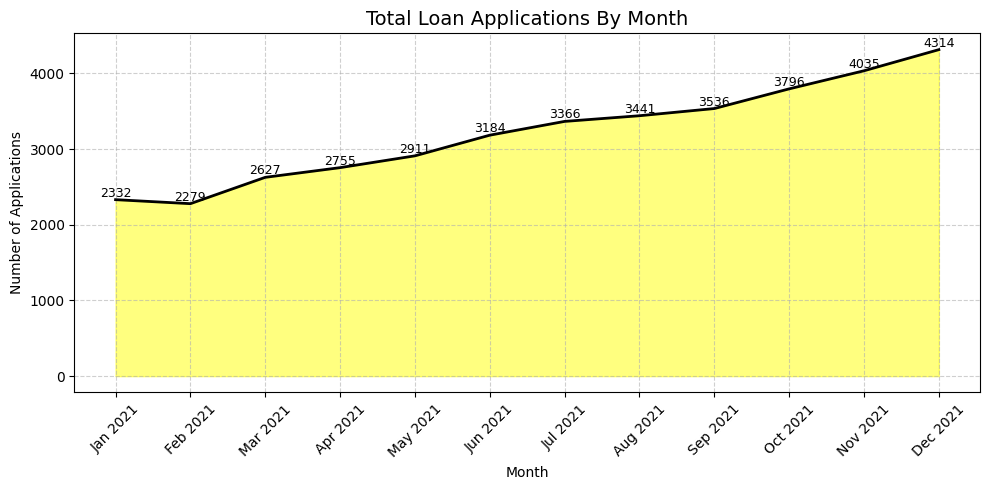

In [27]:
monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['loan_applications_count'],
                 color='yellow',alpha=0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_applications_count'],
                 color='black',linewidth=2)

for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.5,f"{row['loan_applications_count']}",
             ha='center' ,va='bottom' ,fontsize=9, rotation=0 ,color='black')

plt.title('Total Loan Applications By Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()